In [1]:
import numpy as np
import matplotlib.pyplot as plt
from array import array
import hist
import mplhep as hep

In [2]:
#identify hard process events from 100k sample that are all 0s
points = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy')
mask = np.where(np.all(points == 0, axis=(1, 2)))[0]

print(mask)

[51469 68590 79794 97206]


In [3]:
#100K SAMPLE ARRAYS

big_weight = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy') * 1.455 * 10**4
big_ht = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_ht.npy')

big_zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,0]
big_zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,1]
big_zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,2]

big_ljetpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_ljets.npy')[:,0]
big_ljeteta = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_ljets.npy')[:,1]
big_ljetphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_ljets.npy')[:,2]

big_sljetpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_sljets.npy')[:,0]
big_sljeteta = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_sljets.npy')[:,1]
big_sljetphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_sljets.npy')[:,2]

big_njets = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_njets.npy')

In [4]:
dijet_idx1 = np.where(big_njets > 1)[0]

big_ljet_sljet_dist = np.sqrt((big_ljeteta[dijet_idx1] - big_sljeteta[dijet_idx1])**2 + (big_ljetphi[dijet_idx1] - big_sljetphi[dijet_idx1])**2)
big_ljetpt_over_sljetpt = big_ljetpt[dijet_idx1] / big_sljetpt[dijet_idx1]

dijet_idx2 = np.where(big_njets > 0)[0]
big_z_ljet_dist = np.sqrt((big_ljeteta[dijet_idx2] - big_zeta[dijet_idx2])**2 + (big_ljetphi[dijet_idx2] - big_zphi[dijet_idx2])**2)

In [5]:
#10M SAMPLE ARRAYS

vbig_weight = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_weight.npy') * 1.455 * 10**4
vbig_ht = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_ht.npy')
vbig_njets = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_njet.npy')

vbig_zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,0]
vbig_zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,1]
vbig_zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,2]

vbig_ljetpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_ljet.npy')[:,0]
vbig_ljeteta = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_ljet.npy')[:,1]
vbig_ljetphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_ljet.npy')[:,2]

vbig_sljetpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_sljet.npy')[:,0]
vbig_sljeteta = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_sljet.npy')[:,1]
vbig_sljetphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_sljet.npy')[:,2]

In [6]:
dijet_idx3 = np.where(vbig_njets > 1)[0]

vbig_ljet_sljet_dist = np.sqrt((vbig_ljeteta[dijet_idx3] - vbig_sljeteta[dijet_idx3])**2 + (vbig_ljetphi[dijet_idx3] - vbig_sljetphi[dijet_idx3])**2)
vbig_ljetpt_over_sljetpt = vbig_ljetpt[dijet_idx3] / vbig_sljetpt[dijet_idx3]

dijet_idx4 = np.where(vbig_njets > 0)[0]
vbig_z_ljet_dist = np.sqrt((vbig_ljeteta[dijet_idx4] - vbig_zeta[dijet_idx4])**2 + (vbig_ljetphi[dijet_idx4] - vbig_zphi[dijet_idx4])**2)

# PLOT WRT 10M SAMPLE

In [20]:
#'ΔR'
#'Z p_{T}'
#'p_{T,j_{1}}/ p_{T,j_{2}}'

observable = big_njets #observable from 100k sample
bigdata_observable = vbig_njets #observable from 10M sample
logscale = True #whether y-axis should be log scaled or not
quantity = 'N_{jets}' #string for labels and stuff is the observable
numbins = 16 #number of bins
logbins = False #whether bin widths should be log scaled or not
minbin = 0.25 #minimum bin width when log scaled
frac = 25 #fraction of reweighting used for caption in the plot

#100K ORIGINAL WEIGHT
Weight = big_weight

#10M ORIGINAL WEIGHT
bigdata_weight = vbig_weight

# LOAD 100K REWEIGHTED ARRAYS HERE
hardreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_7gev_bigR.npy')
showeredreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_9gev_bigR.npy')
hadronreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_10gev_bigR.npy')

In [21]:
print('Reweighted fractions for hard process, showered, hadronization arrays respectively:')
print(1-len(np.where(hardreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print(1-len(np.where(showeredreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print(1-len(np.where(hadronreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print('----------------------------------------------------------------------')

print(f'Max of 10M observable is: {max(bigdata_observable)}')

Reweighted fractions for hard process, showered, hadronization arrays respectively:
0.2564593810702217
0.23895053351427586
0.2613288629892765
----------------------------------------------------------------------
Max of 10M observable is: 15


In [22]:
hardreweight = np.delete(hardreweight, mask, axis = 0)

In [23]:
hard_observable=observable
if len(observable) == len(big_ljet_sljet_dist):
    print(len(observable))
    Weight = big_weight[dijet_idx1]
    bigdata_weight = vbig_weight[dijet_idx3]
    showeredreweight = showeredreweight[dijet_idx1]
    hadronreweight = hadronreweight[dijet_idx1]
    
    dijet_idx1_new = np.where(np.isin(np.delete(np.arange(len(big_njets)), mask), dijet_idx1))[0]
    hardreweight = hardreweight[dijet_idx1_new]

    mask_relative = [np.where(dijet_idx1 == i)[0][0] for i in mask if i in dijet_idx1]
    hard_observable = np.delete(observable, mask_relative, axis = 0)

elif len(observable) == len(big_z_ljet_dist):
    print(len(observable))
    Weight = big_weight[dijet_idx2]
    bigdata_weight = vbig_weight[dijet_idx4]
    showeredreweight = showeredreweight[dijet_idx2]
    hadronreweight = hadronreweight[dijet_idx2]
    
    dijet_idx1_new = np.where(np.isin(np.delete(np.arange(len(big_njets)), mask), dijet_idx2))[0]
    hardreweight = hardreweight[dijet_idx2_new]

    mask_relative = [np.where(dijet_idx2 == i)[0][0] for i in mask if i in dijet_idx2]
    hard_observable = np.delete(observable, mask_relative, axis = 0)
    
elif len(observable) == len(big_zpt):
    print(len(observable))
    #### remove hard events that are zero --> this comes from kinematic cuts --> why are we doing kinematic cuts on GEN?
    hard_observable = np.delete(observable, mask, axis = 0)
    # hardreweight = np.delete(hardreweight, mask, axis = 0)


print('Length of observable and weight arrays. These must be the same:')
print(len(observable), ',', len(Weight))
print(len(hard_observable), ',', len(hardreweight))

100000
Length of observable and weight arrays. These must be the same:
100000 , 100000
99996 , 99996


In [24]:
#### book and fill histograms
data = bigdata_observable

xmin = min(data) - min(data) / 100.0
xmax = max(data) + max(data) / 100.0

h_bd = hist.Hist(
    hist.axis.Regular(numbins,xmin,xmax,name="data",label="Big data",),
    storage=hist.storage.Weight(), 
)
h_orig = hist.Hist(
    hist.axis.Regular(numbins,xmin,xmax,name="data",label="Original",),
    storage=hist.storage.Weight(), 
)
h_hard = hist.Hist(
    hist.axis.Regular(numbins,xmin,xmax,name="data",label="Hard Reweight",),
    storage=hist.storage.Weight(), 
)
h_shower = hist.Hist(
    hist.axis.Regular(numbins,xmin,xmax,name="data",label="Shower Reweight",),
    storage=hist.storage.Weight(), 
)

h_hadron = hist.Hist(
    hist.axis.Regular(numbins,xmin,xmax,name="data",label="Hadron Reweight",),
    storage=hist.storage.Weight(), 
)

h_bd.fill(bigdata_observable, weight = bigdata_weight)  # Fill with value and weight
h_orig.fill(observable, weight = Weight)
h_hard.fill(hard_observable, weight = hardreweight)
h_shower.fill(observable, weight = showeredreweight)
h_hadron.fill(observable, weight = hadronreweight)

hists = [h_bd, h_orig, h_hard, h_shower, h_hadron]

In [25]:
def ratio_unc(num, denom):
    val_num = num.values()
    val_denom = denom.values()
    var_num = num.variances()
    var_denom = denom.variances()
    ratio = np.divide(val_num, val_denom)

    rel_var = np.divide(var_num, val_num**2, where=val_num!=0) + np.divide(var_denom, val_denom**2, where=val_denom!=0)
    ratio_var = (ratio**2)*rel_var
    return ratio, ratio_var

10M Sample
                           ┌─────────────────────────────────────────────────┐
[  -inf,      0) 0         │                                                 │
[     0, 0.9469) 0.02104   │███▏                                             │
[0.9469,  1.894) 0.07066   │██████████▌                                      │
[ 1.894,  2.841) 0.3237    │████████████████████████████████████████████████ │
[ 2.841,  3.788) 0.3107    │██████████████████████████████████████████████▏  │
[ 3.788,  4.734) 0.1729    │█████████████████████████▋                       │
[ 4.734,  5.681) 0.06753   │██████████                                       │
[ 5.681,  6.628) 0.02272   │███▍                                             │
[ 6.628,  7.575) 0.007325  │█▏                                               │
[ 7.575,  8.522) 0.002371  │▍                                                │
[ 8.522,  9.469) 0.0007511 │▏                                                │
[ 9.469,  10.42) 0.0002164 │             

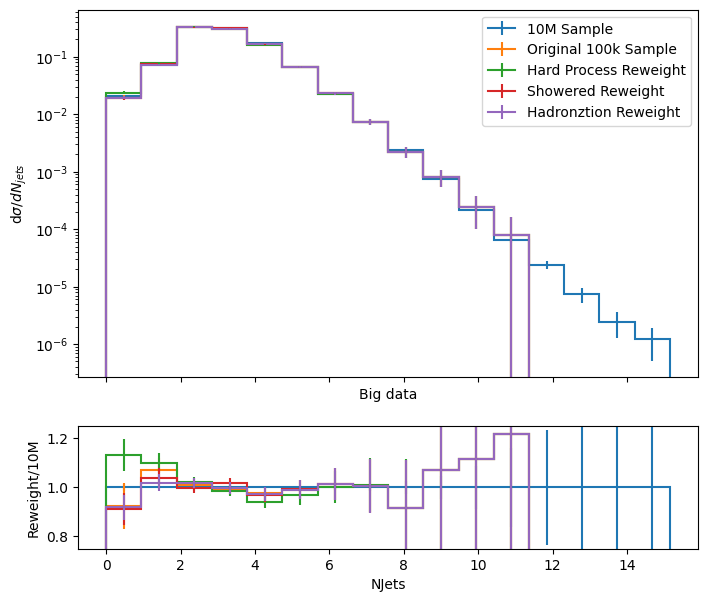

In [26]:
##### Normalize all hists
for i in range(len(hists)): 
    hists[i] = hists[i]/hists[i].sum(flow=False).value

#### Take ratio wrt to 10M sample
h_bd = h_bd/h_bd.sum(flow=False).value
labels = ["10M Sample", "Original 100k Sample", "Hard Process Reweight", "Showered Reweight", "Hadronztion Reweight"]
ratios = []
ratio_uncs = []
for i in range(len(hists)):
    h = hists[i]
    print(labels[i])
    print(hists[i])
    ratio, ratio_var = ratio_unc(h, h_bd)
    print(ratio)
    ratios.append(ratio)
    ratio_uncs.append(ratio_var)
fig, (ax, rax) = plt.subplots(nrows=2,
                    ncols=1,
                    figsize=(8,7),
                    gridspec_kw={"height_ratios": (3, 1)},
                    sharex=True)
bin_centers = h.axes[0].centers
bin_edges = h.axes[0].edges
for i in range(len(ratios)):
    hep.histplot(ratios[i], bins=bin_edges, label=labels[i], ax=rax, yerr = np.sqrt(ratio_uncs[i]))
for i in range(len(hists)):
    hep.histplot(hists[i], label=labels[i], ax=ax)
rax.set_xlabel("NJets")
rax.set_ylabel("Reweight/10M")
ax.set_ylabel(rf"d$\sigma/d{quantity}$")
rax.set_ylim(0.75, 1.25)
ax.set_yscale('log')
ax.legend()
plt.show()

# PLOT WRT 100K SAMPLE

In [14]:
#'ΔR'
#'Z p_{T}'
#'p_{T,j_{1}}/ p_{T,j_{2}}'

observable = big_njets #observable from 100k sample
logscale = True #whether y-axis should be log scaled or not
quantity = 'N_{jets}' #string for labels and stuff is the observable
numbins = 13 #number of bins
logbins = False #whether bin widths should be log scaled or not
minbin = 0.25 #minimum bin width when log scaled
frac = 25 #fraction of reweighting used for caption in the plot

#100K ORIGINAL WEIGHT
Weight = big_weight

# LOAD 100K REWEIGHTED ARRAYS HERE
hardreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_7gev_bigR.npy')
showeredreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_9gev_bigR.npy')
hadronreweight = np.load('/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_10gev_bigR.npy')

In [15]:
print('Reweighted fractions for hard process, showered, hadronization arrays respectively:')
print(1-len(np.where(hardreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print(1-len(np.where(showeredreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print(1-len(np.where(hadronreweight < 0)[0]) / len(np.where(Weight < 0)[0]))
print('----------------------------------------------------------------------')

print(f'Max of 100k observable is: {max(observable)}')

Reweighted fractions for hard process, showered, hadronization arrays respectively:
0.2564593810702217
0.23895053351427586
0.2613288629892765
----------------------------------------------------------------------
Max of 100k observable is: 12


In [16]:
h_orig = h_orig/h_orig.sum(flow=False).value
ratios = []
ratio_uncs = []
for h in hists:
    print(h.values(), h_orig.values())
    ratio, ratio_var = ratio_unc(h, h_orig)
    ratios.append(ratio)
    ratio_uncs.append(ratio_var)

[2.10431785e-02 7.06558373e-02 3.23742129e-01 3.10675882e-01
 1.72867231e-01 6.75332449e-02 2.27171195e-02 7.32539001e-03
 2.37127404e-03 7.51117079e-04 2.16362233e-04 6.59951617e-05
 2.41856403e-05 7.36573415e-06 2.45795737e-06 1.22983732e-06] [ 1.94460101e-02  7.56099525e-02  3.26878171e-01  3.08801031e-01
  1.68652871e-01  6.69538610e-02  2.30292294e-02  7.36774297e-03
  2.17408809e-03  8.05217811e-04  2.41565343e-04  8.05217811e-05
 -4.02608906e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00]
[ 1.94460101e-02  7.56099525e-02  3.26878171e-01  3.08801031e-01
  1.68652871e-01  6.69538610e-02  2.30292294e-02  7.36774297e-03
  2.17408809e-03  8.05217811e-04  2.41565343e-04  8.05217811e-05
 -4.02608906e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00] [ 1.94460101e-02  7.56099525e-02  3.26878171e-01  3.08801031e-01
  1.68652871e-01  6.69538610e-02  2.30292294e-02  7.36774297e-03
  2.17408809e-03  8.05217811e-04  2.41565343e-04  8.05217811e-05
 -4.02608906e-05  0.00000000e+00  0.00

/tmp/ipykernel_91502/2693015452.py:6: RuntimeWarning: divide by zero encountered in divide
  ratio = np.divide(val_num, val_denom)
/tmp/ipykernel_91502/2693015452.py:6: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(val_num, val_denom)


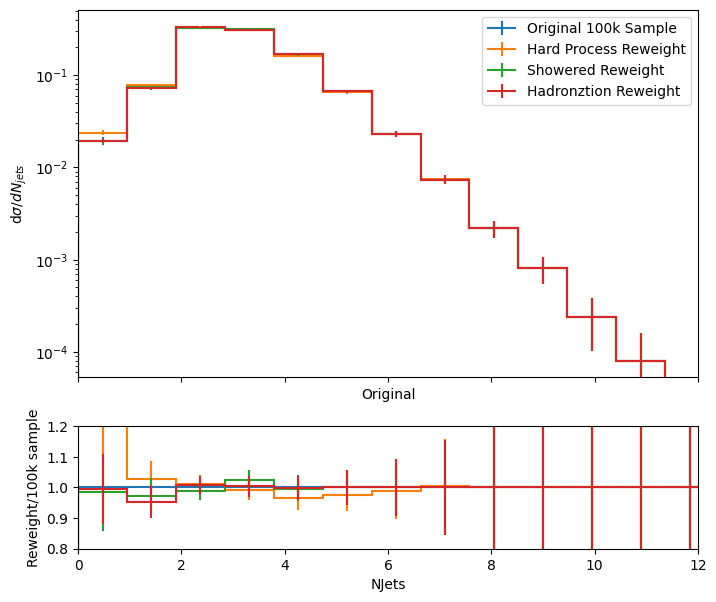

In [17]:
fig, (ax, rax) = plt.subplots(nrows=2,
                    ncols=1,
                    figsize=(8,7),
                    gridspec_kw={"height_ratios": (3, 1)},
                    sharex=True)
bin_centers = h.axes[0].centers
labels = ["10M Sample", "Original 100k Sample", "Hard Process Reweight", "Showered Reweight", "Hadronztion Reweight"]
for i in range(1,len(ratios)):
    hep.histplot(ratios[i], bins=bin_edges, label=labels[i], ax=rax, yerr = np.sqrt(ratio_uncs[i]))
for i in range(1,len(hists)):
    hep.histplot(hists[i], label=labels[i], ax=ax)
rax.set_xlabel("NJets")
rax.set_ylabel("Reweight/100k sample")
ax.set_ylabel(rf"d$\sigma/d{quantity}$")
rax.set_ylim(0.8, 1.2)
rax.set_xlim(0, 12)
ax.set_yscale('log')
ax.legend()
plt.show()